# Political Participation and Social Interactions

In [1]:
from collections import Counter
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import networkx as nx
from sknetwork.ranking import Betweenness
from sknetwork.ranking import Closeness
from sklearn.metrics import normalized_mutual_info_score
from scipy import stats
from IPython.display import clear_output

import matplotlib.pyplot as plt

from utils.general import ccdf, gini, part2dict, array2dict, generate_adjacency_matrix, create_sknetwork_graph_n, create_sknetwork_bipartite, nx_clique_expansion
from utils.community_detection import clustering, mutual_information_btw_equaly_sized_partitions, partition_with_highest_mod
from utils.cluster_composition import aggregated_membership_per_cluster,vectorization_agents_cat, vectorization_agents_orga, inter_similarity, intra_similarity, random_categorization
from utils.centrality import eigenvector, cluster_z_score, diversity, political_participation, political_body, activity_diversity_pol
from utils.load_data import split_data, initialize_hypergraph

## Load Data and Hypergraph Modeling


In [2]:
# Load csv files
activities = pd.read_csv( 'data/activities.csv', index_col = 'Activity')
individuals = pd.read_csv( 'data/individuals.csv', index_col = 'Individual')
orga = pd.read_csv(  'data/organizations.csv', index_col = 'Orga')
# Generate Hypergraph
w= [F for F in activities['Frequency']] # weights
edges = [s.split('/') for s in list( activities ['Individuals'])]
H = initialize_hypergraph(edges, w)

orga_cat = { orga_id : cat for orga_id, cat in zip (orga.index, orga['Category'])} 
FM = { individual_id : list(formal_membership.split("/")) for individual_id, formal_membership in zip (individuals.index, individuals['Membership'])} 


### Describe edge and node degree distributions

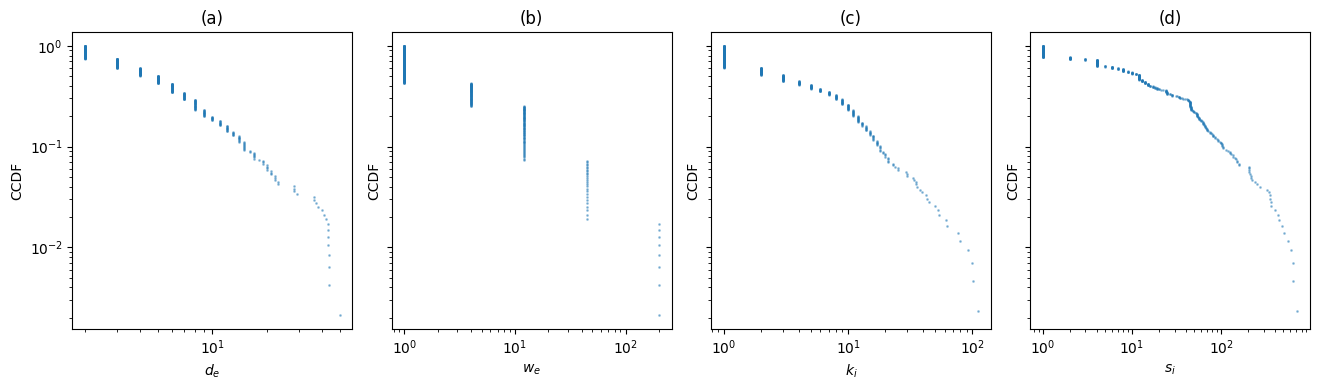

In [3]:
features = [[H.size(e) for e in H.edges()],
        [H.edges[e].weight for e in H.edges()],
        [H.degree(agent) for agent in H.nodes()],
        [H.nodes[agent].strength for agent in H.nodes()]]

notations =[ '$d_e$', '$w_e$', '$k_i$', '$s_i$',]
fig, ax = plt.subplots(1,4, figsize = (13.3,4), sharey = True)
for i, (feature,notation, title) in enumerate(zip(features, notations, ['(a)', '(b)' , '(c)', '(d)'])):
    x,y = ccdf(feature)
    ax[i].set_xlabel(notation)
    ax[i].plot(x, y, marker='o', markersize = 1, linewidth =0, alpha = 0.4)
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
    ax[i].set_ylabel('CCDF')
    ax[i].set_title(title)

plt.tight_layout()
plt.savefig( './out/ccdf_edge_node_props.pdf')

## Community detection algorithms

### Comparing clustering using the hypergraph and its clique expansion
Run both method for different initial node shuffling

In [4]:
nb_itt = 100
start , stop, step = 0 , 5, 0.1
rs = np.arange (start, stop, step)

partitions = pd.DataFrame()
for method in ['Louvain_b', 'Louvain_g']:
    adjacency_matrix = generate_adjacency_matrix(H, method)
    results = pd.DataFrame({'seed': [i  for _ in range(len(rs)) for i in range(nb_itt)],
                             'r': [r for r in rs for _ in range(nb_itt)], 
                             'algo_name' : [method]*(nb_itt*len(rs))}
                             )
    results['Partition'] = results.apply(
        lambda x: clustering(adjacency_matrix, method, res=x['r'], random_state = int(x['seed'])),
        axis=1
    )
    results['q'] = results['Partition'].apply(lambda x: np.max(x) +1)
    partitions = pd.concat([partitions, results], ignore_index = True)


#### Stabily of resuts
Compute mutual information between pairs of partitions for r=1 for both alogrithms separately. The mutual information indicates the similarity of clustering algorithm results. A mutual information is close to 1 indicates a low sensitivity to the initial order of nodes. This reveals the stability of the algorithms.  

In [5]:
algo_name = ['Louvain_g' , 'Louvain_b']
for algo in algo_name:
    ps = partitions[(partitions['r'] == 1) & (partitions['algo_name'] == algo)]['Partition']
    m_i = [ normalized_mutual_info_score (p1,p2) for p1,p2 in itertools.combinations(ps, 2)]
    print(algo, np.mean(m_i), np.std(m_i))

Louvain_g 0.9361620695377193 0.038995261577999006
Louvain_b 0.9408988935414652 0.026102836449114073


#### Difference between the two methods
Compute mutual information between mixed pairs of partitions. Mutual information close to 1 indicates a high similartiy between the results obtained with both algorithms

In [6]:
# Cross mutual information between partitions for r=1 
pgs = partitions[(partitions['r'] == 1) & (partitions['algo_name'] == 'Louvain_g')]['Partition']
pbs = partitions[(partitions['r'] == 1) & (partitions['algo_name'] == 'Louvain_b')]['Partition']
m_i = [ normalized_mutual_info_score (p1,p2) for p1 in pgs for p2 in pbs]
print(np.mean(m_i), np.std(m_i))

0.7533313763848247 0.025470417683750617


Mututal information indicates similarity but not complete alignment. Where is the difference? 
Comparing size of clusters.

In [7]:
def std_cluster_vol(x, labels):
    df = pd.DataFrame({'node': lables, 'cluster': x})
    df['strength'] = df['node'].apply(lambda x: H.nodes[x].strength)
    return df.groupby('cluster').sum()['strength'].std(ddof = 0)

network = create_sknetwork_bipartite(H)
lables = network.names
partitions['std_vol'] = partitions['Partition'].apply(lambda x: std_cluster_vol( x, lables))

In [8]:
print('q_G = ', partitions[partitions['r'] == 1].groupby(['algo_name'])['q'].mean()['Louvain_g'])
print('q_B = ', partitions[partitions['r'] == 1].groupby(['algo_name'])['q'].mean()['Louvain_b'])
print('std_G = ', partitions[(partitions['r'] == 1) & (partitions['algo_name'] == 'Louvain_g')]['std_vol'].mean())
print('std_B = ', partitions[(partitions['r'] == 1) & (partitions['algo_name'] == 'Louvain_b')]['std_vol'].mean())


q_G =  9.82
q_B =  13.68
std_G =  1651.702869128709
std_B =  1123.0108209438145


Hypergraph clustering provides a finer resolution and more balanced partitions.
Compare partition of the same size using mutual information and looking at the standard deviation of clusters volume.

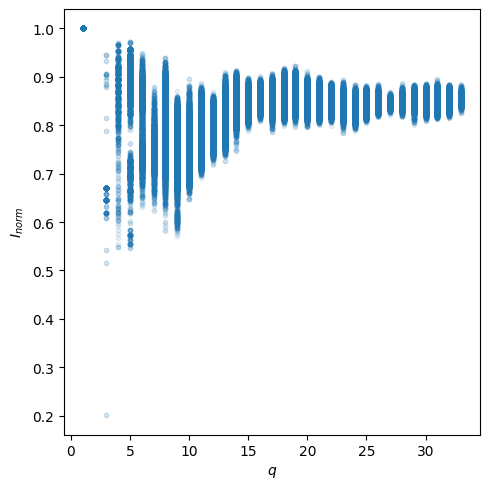

In [9]:
nb_clusters, mi =  mutual_information_btw_equaly_sized_partitions(partitions)

fig,ax = plt.subplots( figsize = (5,5))
ax.scatter(nb_clusters, mi, s =10, alpha =0.1)
ax.set_xlabel('$q$')
ax.set_ylabel(r'$I_{norm}$')
plt.tight_layout()


In [10]:
fig.savefig('./out/MI_vs_nb_clusters.pdf')

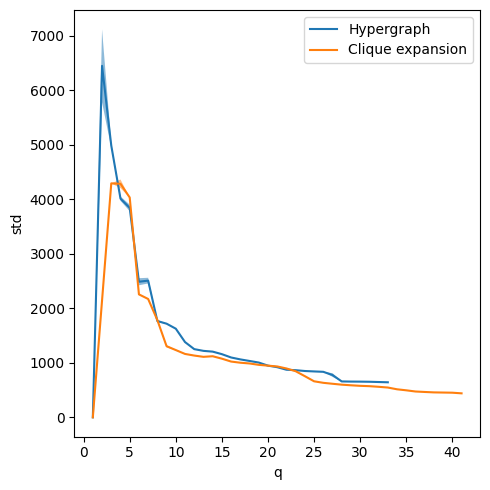

In [11]:
fig, ax =plt.subplots(figsize =(5,5))

for algo_name , label in zip (['Louvain_g', 'Louvain_b'] , ['Hypergraph', 'Clique expansion']) : 
    df = pd.DataFrame( partitions[partitions['algo_name'] == algo_name].groupby(['q'])['std_vol'].mean())
    df['error'] = partitions[partitions['algo_name'] == algo_name].groupby(['q'])['std_vol'].sem(ddof = 0)

    df['std_vol'].plot(ax =ax , label = label )
    ax.fill_between(df.index, df['std_vol']+df['error'],  df['std_vol']-df['error'], alpha = 0.5)
    
ax.legend()
ax.set_ylabel('std')    
plt.tight_layout()
#fig.savefig('./out/std_comm_vol_vs_nb_clusters.pdf')


## Clusters Composition
Select partition with highest modularity for the rest

In [12]:
nb_itt = 700
algo_name = 'Louvain_b'
clusters = array2dict(partition_with_highest_mod(H, algo_name, nb_itt), create_sknetwork_bipartite(H).names) 

/home/azaiez/Documents/These/Politics and Associations/Programs/utils/community_detection.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partitions = pd.concat([partitions, pd.DataFrame({'seed' : i,  'algo_name' :algo_name,  'modularity' : [modularity(adjacency_matrix, algo_name , partition)] } ) ], ignore_index=True )


small clusters gini 0.38709131495126037
large clusters gini 0.6674708733505773


,std_intra,mean_intra,gini,size
6,194.281102,150.962963,6.557991e-01,4076
3,193.679582,123.185185,6.888711e-01,3326
0,128.373113,61.951220,7.326099e-01,2540
2,29.850163,21.033333,6.453660e-01,1893
4,38.520310,30.311111,5.757576e-01,1364
8,58.032319,53.000000,5.534591e-01,1272
5,74.854822,26.825000,8.204334e-01,1073
1,62.008259,33.607143,6.988386e-01,941
13,117.493378,134.142857,4.643237e-01,939
10,25.356793,33.818182,4.203324e-01,744


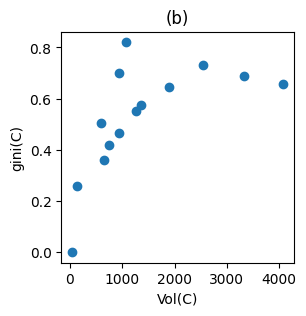

In [13]:
# Mean and std of strength within clusters

ginis = [gini([ H.nodes[agent].strength for agent in c]) for c in clusters.values()]
size = [np.sum([ H.nodes[agent].strength for agent in c]) for c in clusters.values()]
std_intra = [np.std([ H.nodes[agent].strength for agent in c]) for c in clusters.values()]
mean_intra = [np.mean([ H.nodes[agent].strength for agent in c]) for c in clusters.values()]
df = pd.DataFrame({'std_intra' : std_intra, 'mean_intra': mean_intra, 'gini' : ginis, 'size': size})
fig, ax = plt.subplots(figsize = (3,3))
ax.scatter(df['size'], df['gini'])
ax.set_title('(b)')
plt.xlabel('Vol(C)')
plt.ylabel('gini(C)')
plt.savefig('./out/gini_vol.pdf')
print('small clusters gini', df[df['size'] < 1000]['gini'].mean() )
print('large clusters gini', df[df['size'] > 1000]['gini'].mean() )

df.sort_values('size', ascending= False)

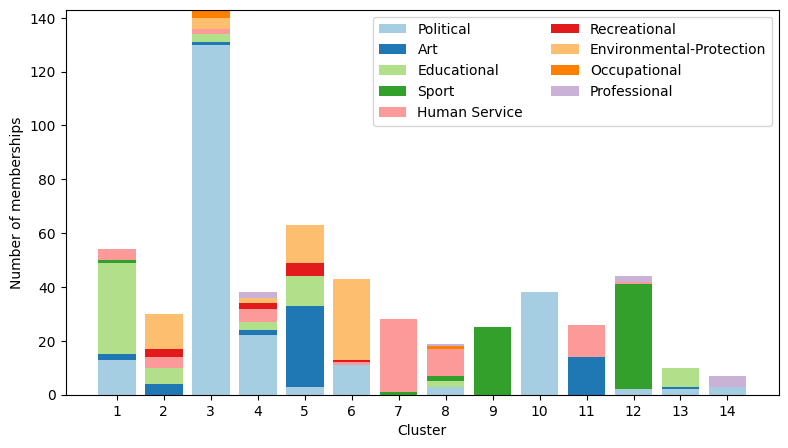

In [14]:
# Cluster composition
cat_c = aggregated_membership_per_cluster(clusters , FM, orga_cat) #dictionary of counters
categories = ['Political','Art', 'Educational', 'Sport', 'Human Service', 'Recreational', 'Environmental-Protection', 'Occupational', 'Professional']
result={}        # dictionary of list of lenght = len(categorie).
for c in clusters.keys():
    result[c] =[]
    for cat in categories:
        if cat in cat_c[c]:
            result[c].append(cat_c[c][cat])
        else:
            result[c].append(0)

fig, ax = plt.subplots(figsize=(9.2, 5))
palette = sns.color_palette( 'Paired', len(categories))
labels = np.array(list(result.keys() )) +1
data = np.array(list(result.values()))
data_cum = data.cumsum(axis=1)
for i, (colname, color) in enumerate(zip(categories, palette)):
    heights = data[:, i]
    starts = data_cum[:, i] - heights
    rects = ax.bar(x=labels, height =heights, bottom=starts,
                    label=colname, color=color)
ax.set_ylabel('Number of memberships')
ax.set_xlabel('Cluster')
ax.set_xticks(labels)
ax.legend(ncol =2, loc='upper right')
fig.savefig('out/categorial composition.pdf')

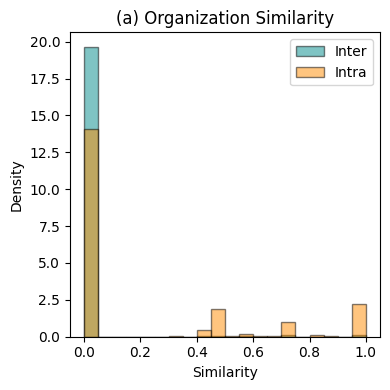

In [15]:
#M = vectorization_agents_cat(clusters, FM , orga_cat)
M = vectorization_agents_orga(clusters, FM , list(orga.index))

cos_intra = intra_similarity(M)
cos_inter = inter_similarity(M)
#Plot orga sim
step = 0.05
bins = np.arange ( 0, 1+step , step)
fig, ax = plt.subplots(figsize=[4,4])
kwargs = {'bins' :bins, 'density': True, 'alpha' : 0.5, 'edgecolor' : 'k'  }
ax.hist(cos_inter, label = 'Inter', color = 'darkcyan', **kwargs)
ax.hist(cos_intra,  label = 'Intra', color = 'darkorange', **kwargs)
ax.set_title('(a) Organization Similarity')
plt.xlabel('Similarity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
fig.savefig('./out/orga_sim.pdf')

In [16]:
nb_itt = 700
algo_name = 'Louvain_b'
clusters = array2dict(partition_with_highest_mod(H, algo_name, nb_itt), create_sknetwork_bipartite(H).names) 

# Compute similarity for random assignment of categories
nb_itt = 500
c_inter = Counter()
c_intra = Counter()

for itt in range (nb_itt):
    print(itt)
    clear_output(wait = True)
    r_orga_cat = random_categorization(orga_cat)
    M = vectorization_agents_cat(clusters, FM , r_orga_cat)
    cos_intra = intra_similarity(M)
    cos_inter = inter_similarity(M)
    c_inter += Counter({i : sim for i , sim in enumerate(cos_inter) })
    c_intra += Counter({i : sim for i , sim in enumerate(cos_intra) })
    
for couple in c_inter.keys():
    c_inter[couple]/=nb_itt
for couple in c_intra.keys():
    c_intra[couple]/=nb_itt
# empirical case    
M = vectorization_agents_cat(clusters, FM , orga_cat)
cos_intra_emp = intra_similarity(M)
cos_inter_emp = inter_similarity(M)


499


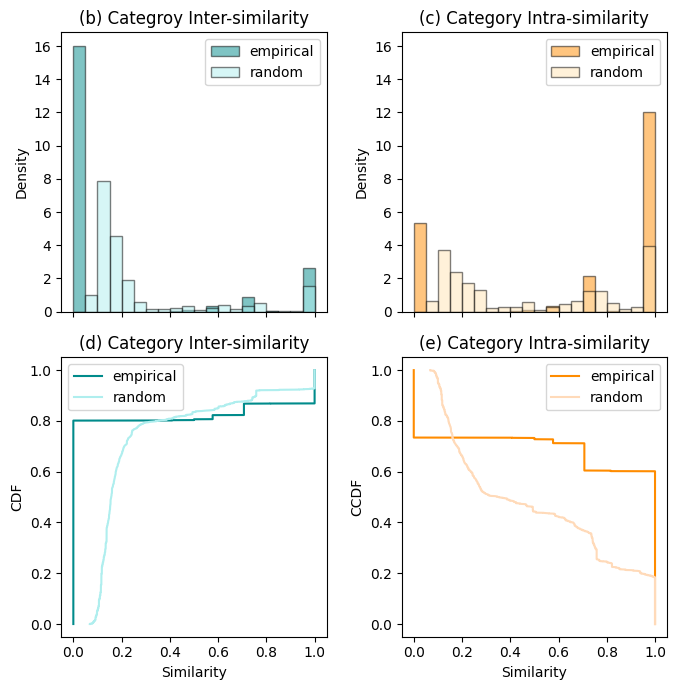

In [17]:
#%matplotlib widget
def cdf (data):
    ''' Complementary cumulative distribution function plot'''
    data = list(data)
    N = len(data)
    x = np.sort(data)
    y =  (np.arange(N) / float(N))
    return x,y 
# Distributions
step = 0.05
bins = np.arange ( 0, 1+step , step)
fig, axs = plt.subplots(2,2, sharex = True, figsize = (7,7))
kwargs = {'bins' :bins, 'density': True, 'alpha' : 0.5, 'edgecolor' : 'k'  }

for ax, similarity , sim_type , colors in zip (axs[0,:],[ [cos_inter_emp,c_inter.values() ],[cos_intra_emp,c_intra.values()]], ['(b) Categroy Inter-similarity', '(c) Category Intra-similarity'], [['darkcyan','paleturquoise' ],['darkorange','moccasin' ]]):  
    ax.hist(similarity[0], label = 'empirical', **kwargs, color =colors[0])
    ax.hist(similarity[1], label = 'random', **kwargs, color = colors[1])
    ax.set_title(sim_type)
    ax.set_ylabel('Density')
    ax.legend()
axs[0, 1].sharey(axs[0, 0])
# Cumulative distribution functions
for ax, similarity , sim_type , colors in zip (axs[1,:],[ [cos_inter_emp,c_inter.values() ],[cos_intra_emp,c_intra.values()]], ['(d) Category Inter-similarity', '(e) Category Intra-similarity'], [['darkcyan','paleturquoise' ],['darkorange','peachpuff' ]]):  
    if 'Inter-similarity' in sim_type:
        x,y = cdf(similarity[0])
        ax.plot(x,y, label = 'empirical',  color =colors[0])
        x,y = cdf(similarity[1])
        ax.plot(x,y, label = 'random', color = colors[1])
        ax.set_ylabel('CDF')

    else:
        x,y = ccdf(similarity[0])
        ax.plot(x,y, label = 'empirical',  color =colors[0])
        x,y = ccdf(similarity[1])
        ax.plot(x,y, label = 'random', color = colors[1])
        ax.set_ylabel('CCDF')

    ax.set_title(sim_type)
    ax.set_xlabel('Similarity')
    ax.legend()
plt.tight_layout()
plt.show()

fig.savefig('./out/random_cat_sim.pdf')

It is more probable to observe an intersimilarity <0.5 in the empirical case thant in the random one. In more probable to observe an intra-similarity >= 0.2 in the empirical case than in the random one.


/home/azaiez/Documents/These/Politics and Associations/Programs/utils/community_detection.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partitions = pd.concat([partitions, pd.DataFrame({'seed' : i,  'algo_name' :algo_name,  'modularity' : [modularity(adjacency_matrix, algo_name , partition)] } ) ], ignore_index=True )
/home/azaiez/Documents/These/Politics and Associations/Programs/utils/community_detection.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partitions = pd.concat([partit

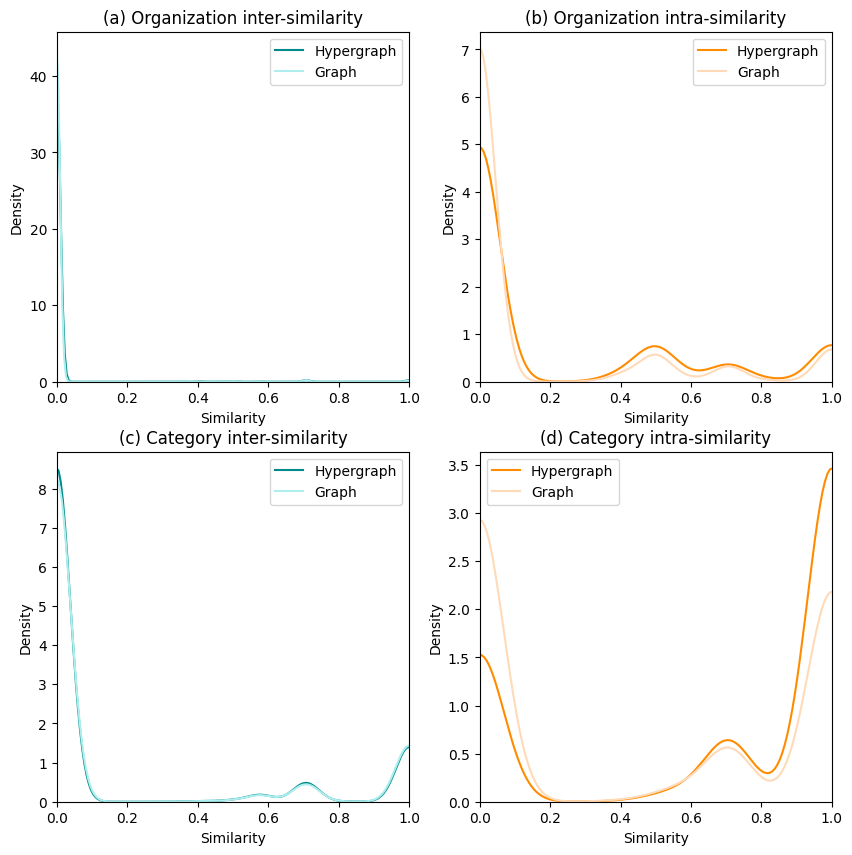

In [18]:
nb_itt = 700
clusters_H = array2dict(partition_with_highest_mod(H, 'Louvain_b', nb_itt), create_sknetwork_bipartite(H).names) 
clusters_G = array2dict(partition_with_highest_mod(H, 'Louvain_g', nb_itt), create_sknetwork_bipartite(H).names) 

# Compare recovery of organizations with H and its clique expansion
fig, ax = plt.subplots(2,2, figsize = (10,10))
kwargs = {'bins' :bins, 'density': True, 'alpha' : 0.5, 'edgecolor' : 'k'  }

for i, similarity_type in enumerate(['Organization', 'Category']):
    if similarity_type == 'Organization':
        M_H = vectorization_agents_orga(clusters_H, FM , list(orga.index))
        M_G = vectorization_agents_orga(clusters_G, FM , list(orga.index))
    elif similarity_type == 'Category':
        M_H = vectorization_agents_cat(clusters_H, FM , orga_cat)
        M_G = vectorization_agents_cat(clusters_G, FM , orga_cat)
    for j, similarity_set in enumerate(['inter', 'intra']):
        if similarity_set == 'inter':
            cos_H = inter_similarity(M_H)
            cos_G = inter_similarity(M_G)
            colors = ['darkcyan','paleturquoise' ]
        elif similarity_set == 'intra':
            cos_H = intra_similarity(M_H)
            cos_G = intra_similarity(M_G)
            colors = ['darkorange','peachpuff' ]
        sns.kdeplot(cos_H, ax = ax[i,j], label = 'Hypergraph', color = colors[0])#, **kwargs)
        sns.kdeplot(cos_G, ax = ax[i,j],  label = 'Graph', color =  colors[1]) #, **kwargs)
        
        ax[i,j].set_xlim(0,1)
        ax[i,j].set_xlabel('Similarity')
        ax[i,j].legend()
ax[0,0].set_title('(a) Organization inter-similarity')
ax[0,1].set_title('(b) Organization intra-similarity')
ax[1,0].set_title('(c) Category inter-similarity')
ax[1,1].set_title('(d) Category intra-similarity')
plt.savefig('./out/orga_recovery_h_g.pdf')

# Centrality

In [19]:
#To compute the diversity coefficient
nb_itt = 700
algo_name = 'Louvain_b'
clusters = array2dict(partition_with_highest_mod(H, algo_name, nb_itt), create_sknetwork_bipartite(H).names) 

/home/azaiez/Documents/These/Politics and Associations/Programs/utils/community_detection.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partitions = pd.concat([partitions, pd.DataFrame({'seed' : i,  'algo_name' :algo_name,  'modularity' : [modularity(adjacency_matrix, algo_name , partition)] } ) ], ignore_index=True )


In [20]:
#Strength
individuals['Strength'] = [H.nodes[agent].strength for agent in individuals.index]
#Diversity
nb_itt = 3
algo_name = 'Louvain_b'
clusters = array2dict(partition_with_highest_mod(H, algo_name, nb_itt), create_sknetwork_bipartite(H).names)    
individuals['Diversity'] = diversity(H , clusters)
#Eigenvector
individuals['EV linear'] = eigenvector(H,'linear')
individuals['EV log exp'] = eigenvector(H, 'log exp')
individuals['EV max']  = eigenvector(H, 'max' )
#Core to periphery 
individuals['Cluster z-score']  = cluster_z_score(H,clusters)
# Betweenness and closeness centrality
I = nx_clique_expansion(H)
btw_weighted_nx = nx.betweenness_centrality(I, normalized = True, weight = 'weight')
closeness = nx.closeness_centrality(I, distance = 'weight')
individuals['Betweenness'] = [ btw_weighted_nx[agent]  for agent in individuals.index]
individuals['Closeness'] = [ closeness[agent]  for agent in individuals.index]
#Political participation
pol = political_body(orga_cat = orga_cat, individuals = individuals)
individuals['Political Participation'] = political_participation(H , individuals)


/home/azaiez/Documents/These/Politics and Associations/Programs/utils/community_detection.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  partitions = pd.concat([partitions, pd.DataFrame({'seed' : i,  'algo_name' :algo_name,  'modularity' : [modularity(adjacency_matrix, algo_name , partition)] } ) ], ignore_index=True )


under tolerance value satisfied


/home/azaiez/Documents/These/Politics and Associations/Programs/utils/centrality.py:29: RuntimeWarning: divide by zero encountered in log
  return np.log(x)
/home/azaiez/Documents/These/Politics and Associations/Programs/utils/centrality.py:60: RuntimeWarning: overflow encountered in matmul
  v = np.sqrt(y0 * psi( np.transpose(B) @ N @ np.nan_to_num(phi(x0))))


under tolerance value satisfied
under tolerance value satisfied


In [21]:
P_corr = individuals.groupby(['Political Body']).corr( numeric_only = True)['Political Participation']['Y']
n_P_corr = individuals.groupby(['Political Body']).corr( numeric_only = True)['Political Participation']['N']
pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index)
#print( pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index).to_latex(float_format = '%.3f'))

<>:3: DeprecationWarning: invalid escape sequence '\P'
<>:3: DeprecationWarning: invalid escape sequence '\P'
/tmp/ipykernel_908/4161240720.py:3: DeprecationWarning: invalid escape sequence '\P'
  pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index)


,P,V\P
Strength,0.989706,0.572188
Diversity,0.799571,0.809699
EV linear,0.800339,0.138757
EV log exp,0.883571,0.184704
EV max,0.074107,0.402421
Cluster z-score,0.686640,0.512454
Betweenness,0.436913,0.585323
Closeness,0.098571,0.134287
Political Participation,1.000000,1.000000


In [22]:
individuals.groupby('Political Body')['Political Participation'].apply(gini)['Y']

0.8069930854814511

In [23]:
from scipy.stats import pearsonr
x,y = activity_diversity_pol(H,clusters, dict (individuals['Political Body']) )
print(pearsonr(x,y))


PearsonRResult(statistic=0.13980042960318853, pvalue=0.0022836294907827444)


### Correlation political participation and centralities

In [24]:
P_corr = individuals.groupby(['Political Body']).corr( numeric_only = True)['Political Participation']['Y']
n_P_corr = individuals.groupby(['Political Body']).corr( numeric_only = True)['Political Participation']['N']
pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index)
#print( pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index).to_latex(float_format = '%.3f'))


<>:3: DeprecationWarning: invalid escape sequence '\P'
<>:3: DeprecationWarning: invalid escape sequence '\P'
/tmp/ipykernel_908/705444911.py:3: DeprecationWarning: invalid escape sequence '\P'
  pd.DataFrame({'P': P_corr , 'V\P': n_P_corr}, index = P_corr.index)


,P,V\P
Strength,0.989706,0.572188
Diversity,0.799571,0.809699
EV linear,0.800339,0.138757
EV log exp,0.883571,0.184704
EV max,0.074107,0.402421
Cluster z-score,0.686640,0.512454
Betweenness,0.436913,0.585323
Closeness,0.098571,0.134287
Political Participation,1.000000,1.000000


In [25]:
# Point Biserialr correlation
centralities_label = list(individuals.select_dtypes(include=np.number).columns)
df = individuals.replace({'President': { 'P' : 1, 'N' : 0 } })
pointbiserial = df.groupby(['Political Body'])[centralities_label].corrwith(df['President'], method=stats.pointbiserialr)
pointbiserial.loc['N'].transpose()
#print( pointbiserial.loc['N'].transpose().to_latex(float_format = '%.3f'))

/tmp/ipykernel_908/1191975754.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = individuals.replace({'President': { 'P' : 1, 'N' : 0 } })


,0,1
Strength,0.243073,9.387226e-05
Diversity,0.397216,5.430137e-11
EV linear,0.035827,5.705573e-01
EV log exp,0.004673,9.410406e-01
EV max,0.297883,1.402629e-06
Cluster z-score,0.312399,3.938366e-07
Betweenness,0.368684,1.451241e-09
Closeness,0.133553,3.372985e-02
Political Participation,0.383531,2.731531e-10


# Network visualiation


In [26]:
I = create_sknetwork_bipartite(H)
s_edges, s_weights = split_data(edges , w)
B = nx.Graph()
# Add nodes with the node attribute "bipartite"
for e , c in zip(I.names_col , clusters[1]):
    B.add_node(e, bipartite= 'edge', cluster = c+1)
for a , c in zip(I.names , clusters[0]):
    B.add_node(a, bipartite= 'node', cluster = c+1 , strength = H.nodes[a].strength )
# Edges to form a bipartite network
for edge , node , w_ in zip (s_edges[0] , s_edges[1] , s_weights):
    B.add_edge( edge, node , weight =w_)

nx.write_gexf(B, "./out/Network.gexf")
    

TypeError: can only concatenate str (not "int") to str